# Создание классификатора сумок и обуви с использованием трансферного обучения.

In [4]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


С веб-сайтов закачали примерно по 100 цветных изображений сумок и обуви, упаковал их в ZIP-архив и разместил в Dropbox.

Приведённый ниже код загружает и распаковывает этот ZIP-архив, чтобы Colab мог получить к нему доступ.

In [4]:
#!wget -q -P ./ https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
#!unzip -qq handbags-shoes.zip

Разделим набор данных на обучающую, валидационную и тестовую выборки.

In [5]:
import pathlib, shutil
from itertools import islice
base_dir = pathlib.Path("./handbags-shoes")

In [6]:
for category in ('handbags', 'shoes'):
    fnames = list((base_dir/category).iterdir())
    dir = base_dir / 'train' / category
    dir.mkdir(parents=True, exist_ok = True)
    
    for fname in fnames[:50]:
        shutil.copy(src=fname, dst=dir)

    dir = base_dir / 'validation' / category
    dir.mkdir(parents=True, exist_ok = True)
    for fname in fnames[50:75]:
        shutil.copy(src=fname, dst=dir)

    dir = base_dir / 'test' / category
    dir.mkdir(parents=True, exist_ok = True)
    for fname in fnames[75:]:
        shutil.copy(src=fname, dst=dir)
    
    

Приведённый выше код создаёт следующую структуру каталогов:

train/   
..handbags/         
..shoes/    
validation/    
..handbags/       
..shoes/         
test/    
..handbags/     
..shoes/   




---



---


При работе с изображениями в формате JPEG мы будем следовать следующему процессу:

1. Считывание изображений JPEG
2. Преобразование изображений JPEG в тензоры
3. Изменение их размера до стандартного (поскольку изображения, полученные путем веб-скрейпинга, могут иметь разные размеры)
5. Группировка в пакеты (мы будем использовать пакеты по 32 изображения).

К счастью, Keras предоставляет нам единую функцию, которая выполняет все эти действия за один раз! (Ref: [image manipulation functions](https://keras.io/api/preprocessing/image/))

In [7]:
train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'train',
    image_size = (224, 224),
    batch_size = 32)
validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'validation',
    image_size = (224, 224),
    batch_size = 32)
test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'test',
    image_size = (224, 224),
    batch_size = 32)

Found 96 files belonging to 2 classes.
Found 49 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [8]:
for images, _ in train_dataset.take(1):
    print(images[0].shape)

(224, 224, 3)


    

---

Мы будем работать с ResNet-50 (а не с ResNet-34, как показано на рисунке ниже), поскольку он поставляется в комплекте с Keras.

Ознакомьтесь с доступными предварительно обученными моделями в [Keras](https://keras.io/api/applications/) и на [Tensorflow](https://www.tensorflow.org/hub).



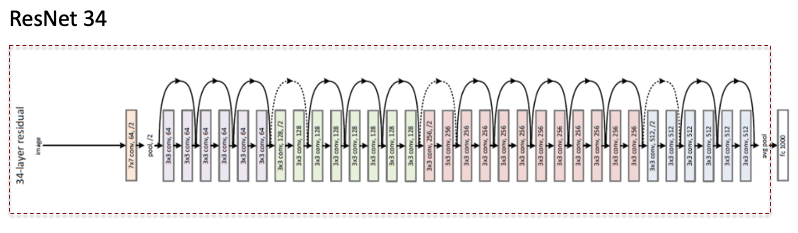

In [9]:
resnet50_base = keras.applications.ResNet50(
    weights='imagenet',
    include_top = False,
    input_shape = (224, 224, 3))

In [11]:
resnet50_base.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Далее мы пропускаем наш набор данных через "безголовую ResNet", чтобы получить преобразованные, "умные" входные данные.


In [10]:
def get_features_and_labels(dataset):
  all_features = []
  all_labels = []
  for images, labels in dataset:
    preprocessed_images = keras.applications.resnet50.preprocess_input(images)
    features = resnet50_base.predict(preprocessed_images)
    all_features.append(features)
    all_labels.append(labels)
  return np.concatenate(all_features), np.concatenate(all_labels)

In [11]:
train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step


Какова форма тензора, получаемого в результате работы «безголовой» модели ResNet?


In [54]:
train_features.shape

(96, 7, 7, 2048)

Эти тензоры, получаемые из "безголовой" ResNet, представляют собой интеллектуальные средства представления данных, и мы можем просто прикрепить их к небольшой нейронной сети.  

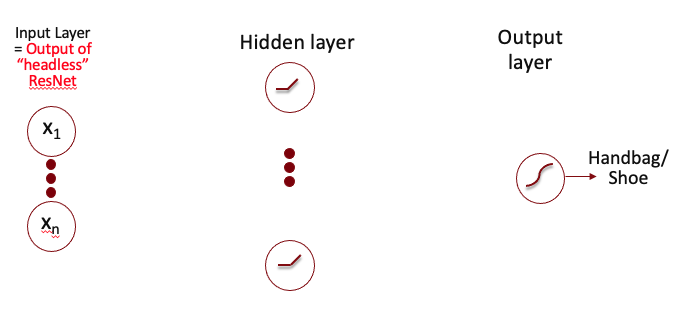


In [12]:
input = keras.Input(shape=(7, 7, 2048))

h = keras.layers.Flatten()(input)

h = keras.layers.Dense(256, activation="relu")(h)

h = keras.layers.Dropout(0.5)(h) # first time we are using this!

output = keras.layers.Dense(1, activation="sigmoid")(h)

model = keras.Model(input, output)

In [13]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [14]:
history = model.fit(train_features,
                    train_labels,
                    epochs=10,
                    validation_data=(val_features, val_labels))

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.7708 - loss: 4.7007 - val_accuracy: 0.9592 - val_loss: 1.1772
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.9792 - loss: 1.2505 - val_accuracy: 0.9796 - val_loss: 0.5099
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 1.0000 - loss: 9.2404e-07 - val_accuracy: 0.9796 - val_loss: 0.1970
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 1.0000 - loss: 1.2693e-22 - val_accuracy: 1.0000 - val_loss: 1.6870e-06
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 4.4408e-09
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.9896 - loss: 0.2666 - val_accuracy: 0.9796 - val_loss: 0.3224
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_

In [15]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

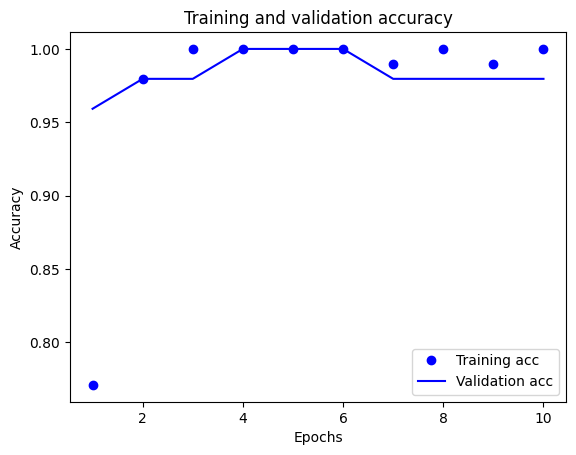

In [16]:
plot_acc_curves(history)

In [17]:
model.evaluate(test_features, test_labels)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9750 - loss: 1.0448


[1.0448448657989502, 0.9750000238418579]

Точность как обучения, так и проверки очень высока! Это выглядит многообещающе!

In [22]:
def predict_image(im):
    img = keras.utils.load_img(im, target_size=(224,224))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    arr = keras.utils.img_to_array(img)
    
    arr = keras.applications.resnet50.preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)
    arr = resnet50_base(arr)
    pred = model.predict(arr)
    pred = "SHOE" if pred > 0.5 else "HANDBAG"
    print("************************************\n\n")
    print(f"...........it is a {pred}!")
    print("\n\n************************************\n\n")

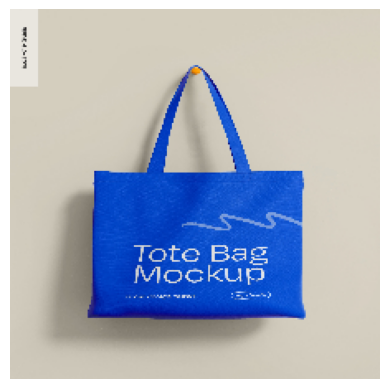

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
************************************


...........it is a HANDBAG!


************************************




In [23]:
predict_image("bag.jpg")

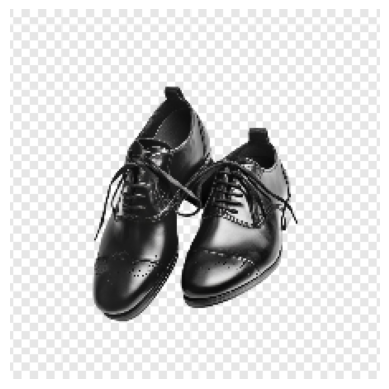

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
************************************


...........it is a SHOE!


************************************




In [24]:
predict_image("shoes.jpg")